In [1]:
%load_ext autoreload
%autoreload 2

import platform
import pandas as pd
import os
import sys

system = platform.system()
if system == 'Linux':
    home = '/home/gerard/'
elif system == 'Darwin':
    home = '/Users/gerard/'
elif system == "Windows":
    home = 'C:/Users/cviko/'


try:
    sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *
except:
    path2add = home + 'analysis/confocal/src'
    sys.path.append(path2add)
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *

home = home + 'data/confocal/'



16-Aug-26 21:13:12 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


In [2]:
def df_separator(df):
    # 5x vs 1x
    keys = ['5x', '1x', '5x.alpha_', '5x.alphaprime_','5x.gamma_', '1x.alpha_', '1x.alphaprime_','1x.gamma_']
    dict_results = dict.fromkeys(keys) 
    for k in keys:
        ks = k.split('.')
        if len(ks) == 1:
            dict_results[k] = df[df['name'].str.contains(k, case=False, na=False)]
        else:
            dict_results[k] = df[
                            df['name'].str.contains(ks[0], case=False, na=False) &
                            df['name'].str.contains(ks[1], case=False, na=False)
                                                    ]
    return(dict_results)


In [3]:

user = 'Carmina'
dates = [
   # '2026_06_05',
    '2026_06_15', 
    '2026_06_25'
    ]
csv_files = [
    #'coloc_results', #coloc_results_2_raw',#'coloc_results_2', #'coloc_results
    'coloc_results',
    'coloc_results',

]

rows2drop = [
           # [],
            [
                'dec02_5x_brain3gamma_R8', 
                'dec02_5x_brain4alpha_L16' 
            ],
            []
                ]



df_list = [] 
for i, date in enumerate(dates):
    path_csv = home + date + '_' + user + f'/{csv_files[i]}.csv'
    df = pd.read_csv(path_csv)

    #TO EXCLUDE SOME ROWS:
    if rows2drop[i]:
        for name in rows2drop[i]:
   
            df = df.drop(df[df["name"] == name].index).reset_index(drop=True)
    ###########
    df_list.append(df)

pooled = (
    pd.concat(df_list, keys=dates, names=["date"])
    .reset_index(level="date")      # moves 'date' level out of the index into a column
    .reset_index(drop=True)         # replaces the remaining old-index level with plain 0..n
)
print(pooled.columns)
print(pooled['date'])
print(pooled['name'])






Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'density_HSP_syn', 'density_HSP_non_syn',
       'density_Mito_syn', 'density_Mito_non_syn',
       'MB_total_pearson_r HSP-Mito', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_pearson_r HSP-Mito',
       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP',
       'MB_syn_odds_ratio', 'MB_syn_enrichment',
       'MB_non_syn_pearson_r HSP-Mito', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', '

In [4]:
#pooled[['name','MB_total_pearson_r HSP-Mito','MB_syn_pearson_r HSP-Mito','MB_non_syn_pearson_r HSP-Mito']]
#pooled[['name','MB_total_enrichment','MB_total_odds_ratio']]
#pooled[['date','name','snr_min_HSP_Mito','MB_total_enrichment','MB_total_odds_ratio']]


Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_fraction of HSP in Mito',
       'MB_syn_fraction of Mito in HSP', 'MB_syn_odds_ratio',
       'MB_syn_enrichment', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'snr_BRP', 'snr_HSP', 'snr_Mito',
       'snr_min_HSP_Mito']

Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_fraction of HSP in Mito',
       'MB_syn_fraction of Mito in HSP', 'MB_syn_odds_ratio',
       'MB_syn_enrichment', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 
       
       'MB_syn_share of total HSP-Mito overlap', <-----------
       'MB_non_syn_share of total HSP-Mito overlap',<-----------
       'MB_syn_HSP-Mito colocalization density',<-----------
       'MB_non_syn_HSP-Mito colocalization density',<-----------
       
       
        'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],


Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 
       
       'density_HSP_syn', <-----------
       'density_HSP_non_syn', <-----------
       'density_Mito_syn', <-----------
       'density_Mito_non_syn',<-----------
       
       
       'MB_total_fraction of HSP in Mito', 'MB_total_fraction of Mito in HSP',
       'MB_total_odds_ratio', 'MB_total_enrichment',
       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP',
       'MB_syn_odds_ratio', 'MB_syn_enrichment',
       'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],
      dtype='str')

Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'density_HSP_syn', 'density_HSP_non_syn',
       'density_Mito_syn', 'density_Mito_non_syn',
       
       'MB_total_pearson_r HSP-Mito', <-----------
       
       'MB_total_fraction of HSP in Mito','MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 
       
       'MB_syn_pearson_r HSP-Mito', <-----------

       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP','MB_syn_odds_ratio','MB_syn_enrichment',
       
       'MB_non_syn_pearson_r HSP-Mito', <-----------
       
       'MB_non_syn_fraction of HSP in Mito','MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 
       
       'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],
      dtype='str')

In [5]:
df_dict = df_separator(pooled)
print(df_dict.keys())
df_5x_1x = pd.concat([df_dict['5x'], df_dict['1x']], axis=1)
#df_5x_1x.head(10)
#fast_plotter(['prop_MB-HSP_in_syn'], df=df_5x_1x, ylabel='', title=title,
                        # bar_color=[['pink', 'hotpink']], quietStats=False, figsize=(6,6), legend=True)

dict_keys(['5x', '1x', '5x.alpha_', '5x.alphaprime_', '5x.gamma_', '1x.alpha_', '1x.alphaprime_', '1x.gamma_'])


   prop_MB-HSP_in_syn_5x  prop_MB-HSP_in_syn_1x
0                  0.193                  0.251
1                  0.120                  0.250
2                  0.056                  0.229
3                  0.045                  0.188
4                  0.187                  0.181
5                  0.166                  0.071
6                  0.035                  0.134
7                    NaN                  0.138
8                    NaN                  0.045
9                    NaN                  0.140
['prop_MB-HSP_in_syn_5x', 'prop_MB-HSP_in_syn_1x']

---------- STATS ----------
prop_MB-HSP_in_syn_5x
  W statistic = 0.8597
  p-value     = 0.1504
  → Data look approximately normal

prop_MB-HSP_in_syn_1x
  W statistic = 0.9349
  p-value     = 0.4353
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.0194
p-value   = 0.8908
→ Variances are not significantly different

One-way ANOVA
F statistic = 1.3696
p-value     = 0.2580
→ No significant differen

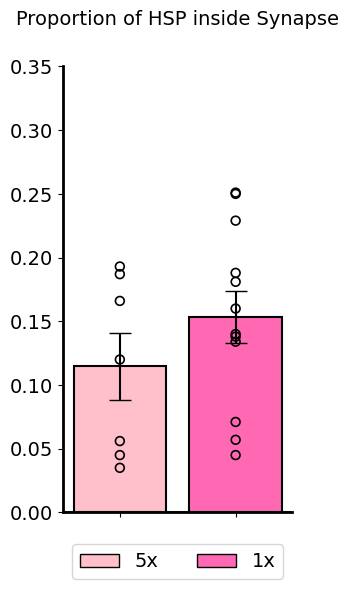

   prop_MB-Mito_in_syn_5x  prop_MB-Mito_in_syn_1x
0                   0.166                   0.261
1                   0.122                   0.236
2                   0.057                   0.204
3                   0.047                   0.203
4                   0.200                   0.186
5                   0.173                   0.027
6                   0.030                   0.125
7                     NaN                   0.128
8                     NaN                   0.036
9                     NaN                   0.132
['prop_MB-Mito_in_syn_5x', 'prop_MB-Mito_in_syn_1x']

---------- STATS ----------
prop_MB-Mito_in_syn_5x
  W statistic = 0.8945
  p-value     = 0.2990
  → Data look approximately normal

prop_MB-Mito_in_syn_1x
  W statistic = 0.9113
  p-value     = 0.2217
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.2821
p-value   = 0.6022
→ Variances are not significantly different

One-way ANOVA
F statistic = 0.7466
p-value     = 0.3996

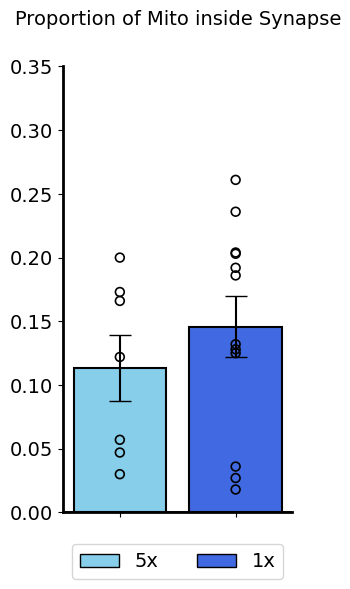

In [6]:

#colmns2plot = ['MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito']
#colmns2plot = ['MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP']

#colmns2plot = ['MB_syn_enrichment','MB_non_syn_enrichment']
#colmns2plot = ['MB_syn_odds_ratio', 'MB_non_syn_odds_ratio']
#colmns2plot = ['MB_syn_share of total HSP-Mito overlap', 'MB_non_syn_share of total HSP-Mito overlap',]
#colmns2plot = ['MB_syn_HSP-Mito colocalization density','MB_non_syn_HSP-Mito colocalization density']

colmns2plot = ['prop_MB-HSP_in_syn', 
               'prop_MB-Mito_in_syn'
               ]


titles= ['Proportion of HSP inside Synapse', 
         'Proportion of Mito inside Synapse',
         ]


colors = [["pink","hotpink"],["skyblue","royalblue"],["lightgreen","seagreen"],["gold","darkorange"]]



        
        
ks = ['5x', '1x']     
for jj, col in enumerate(colmns2plot):
    all_df = pd.DataFrame()
    col_data = {}
    new_col_list = []
    for k in ks:
        df_k = df_dict[k]
        new_col = f"{col}_{k}"
        new_col_list.append(new_col)
   
        col_data[new_col] = df_k[col].reset_index(drop=True)
        
    all_df = pd.concat(col_data, axis=1)
    print(all_df.head(10))
    print(new_col_list)

    bar_color = colors[jj]#colors[j][:len(colmns2plot)] * len(key_group)
    title = titles[jj]

    fast_plotter(new_col_list, df= all_df, ylabel='', ylim=[0,0.35], labels=ks, bar_color=bar_color, title=title,title_font_size=14, quietStats=False, figsize=(3,6), legend=True)


***GENERAL DESCRIPTION OF THE DISTRIBUTIONS:

## Colocalization: synapse vs non-synapse

Four figures, one per metric, each comparing `MB_syn_*` vs `MB_non_syn_*` directly.

- **Paired test** (`paired=True` -> Wilcoxon signed-rank, not the unpaired Mann-Whitney/ANOVA path): syn and non-syn values come from the *same* sample/animal, so this is a within-subject comparison, not two independent groups. This is also much better-powered than the earlier 5X-vs-1X comparisons, since pairing removes animal-to-animal variability entirely (~19 paired samples here vs 2-4 independent animals per condition there).
- **`MB_total` deliberately excluded** — it's the pooled combination of syn+non_syn from the same image, not a third independent group, so including it in the same statistical comparison would violate independence.
- **Odds ratio plotted as `log(OR)`**, per the log-scale pooling convention already established in `colocalization_metrics_explanation.md` (OR is a right-skewed ratio, null at 1 — averaging it on the raw scale is biased). Enrichment and the two fraction metrics are plotted on the raw/linear scale, consistent with that same doc.
- Training condition (5x/1x) intentionally left out here — this is the syn-vs-non-syn question on its own, pooled across condition, kept separate from the condition comparison to avoid re-importing its confounds/power problems into a currently clean comparison.

### Interpreting the log(Odds Ratio) plot

- **Zero is the reference, not an arbitrary baseline** — `log(OR=1) = 0`, and OR=1 means "no association beyond chance." The plot already draws a horizontal line at 0 (`plot_bars_with_sem3_test`'s baseline), so read each bar relative to that line:
  - **Above 0** -> OR > 1 -> that compartment shows more HSP-Mito co-occurrence than chance.
  - **At/near 0**, especially if the SEM error bar crosses the line -> not distinguishable from independence in that compartment, regardless of what the other bar shows.
  - **Below 0** -> OR < 1 -> less overlap than chance predicts (active exclusion, a different story from "no association").
- **Converting a bar height back to an actual OR**: `OR = exp(log(OR))`. E.g. a bar at 1.5 means OR ~= e^1.5 ~= 4.48 — report *this* number in text/results, not the log value itself. The log scale is for the plot and the statistics, not for reporting.
- **Why log specifically**: it turns multiplicative symmetry into additive symmetry. OR=2 and OR=0.5 are equally strong associations in opposite directions, but look wildly asymmetric on a raw scale (2 vs 0.5); on the log scale they're +0.693 and -0.693 -- equidistant from zero. This is why OR should never be averaged/plotted on its raw scale (a few large ORs would dominate a linear mean and misrepresent the "typical" effect).
- **Reading the gap between the synapse and non-synapse bars**: subtracting two log(OR) values gives `log(OR_syn / OR_non_syn)` — a **ratio**, not a difference in absolute strength. A gap of 0.7 means `OR_syn` is `e^0.7 ~= 2.0x` larger than `OR_non_syn`, i.e. colocalization strength is about twice as strong inside synapses -- not "0.7 units" stronger.
- **What the significance bracket does and doesn't tell you**: the paired Wilcoxon test compares synapse vs non-synapse *within the same samples* — a significant result means synaptic and non-synaptic OR reliably differ from each other within-brain. It does **not** tell you whether either compartment individually is significantly above chance (OR != 1) — that's answered separately by whether each bar (with its SEM) sits clearly away from the zero line.


---------- STATS ----------
MB_syn_fraction of HSP in Mito
  W statistic = 0.9714
  p-value     = 0.9081
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.9896
  p-value     = 0.9925
  → Data look approximately normal

Brown-Forsythe test
Statistic = 3.9989
p-value   = 0.0687
→ Variances are not significantly different

MB_syn_fraction of HSP in Mito
  W statistic = 0.9714
  p-value     = 0.9081
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.9896
  p-value     = 0.9925
  → Data look approximately normal

Paired t-test
t statistic = 4.7224
p-value     = 0.0032
→ Significant difference between groups

  Matched-pairs rank-biserial r = 1.0000
  Effect size: large

group: Synapse, mean: 0.3712857142857143, sem: 0.054863342903598414
group: Non-synapse, mean: 0.21714285714285714, sem: 0.02319321387966806


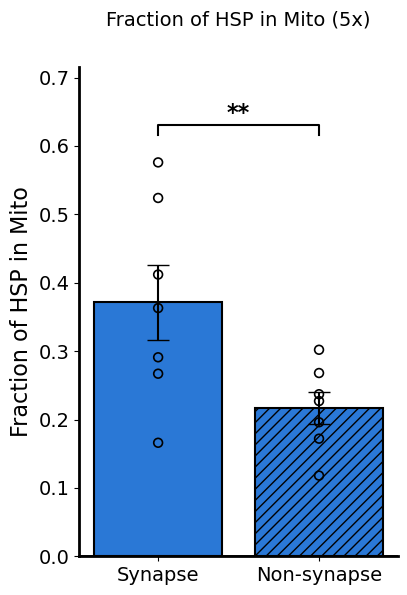


---------- STATS ----------
MB_syn_fraction of Mito in HSP
  W statistic = 0.9290
  p-value     = 0.5421
  → Data look approximately normal

MB_non_syn_fraction of Mito in HSP
  W statistic = 0.9457
  p-value     = 0.6908
  → Data look approximately normal

Brown-Forsythe test
Statistic = 2.3028
p-value   = 0.1550
→ Variances are not significantly different

MB_syn_fraction of Mito in HSP
  W statistic = 0.9290
  p-value     = 0.5421
  → Data look approximately normal

MB_non_syn_fraction of Mito in HSP
  W statistic = 0.9457
  p-value     = 0.6908
  → Data look approximately normal

Paired t-test
t statistic = 3.8205
p-value     = 0.0088
→ Significant difference between groups

  Matched-pairs rank-biserial r = 1.0000
  Effect size: large

group: Synapse, mean: 0.24814285714285716, sem: 0.04166843533661134
group: Non-synapse, mean: 0.143, sem: 0.017211568645480724


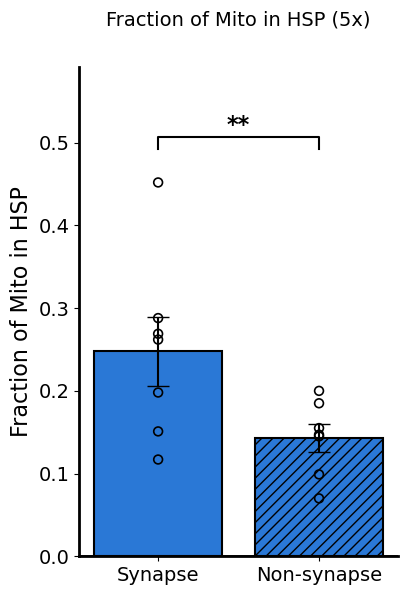


---------- STATS ----------
log_MB_syn_odds_ratio
  W statistic = 0.9238
  p-value     = 0.4998
  → Data look approximately normal

log_MB_non_syn_odds_ratio
  W statistic = 0.9672
  p-value     = 0.8774
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.8555
p-value   = 0.3732
→ Variances are not significantly different

log_MB_syn_odds_ratio
  W statistic = 0.9238
  p-value     = 0.4998
  → Data look approximately normal

log_MB_non_syn_odds_ratio
  W statistic = 0.9672
  p-value     = 0.8774
  → Data look approximately normal

Paired t-test
t statistic = 2.2861
p-value     = 0.0623
→ No significant difference detected

  Matched-pairs rank-biserial r = 1.0000
  Effect size: large

group: Synapse, mean: 0.7893428557680676, sem: 0.1945592307992625
group: Non-synapse, mean: 0.5504868629083063, sem: 0.11161010333155436


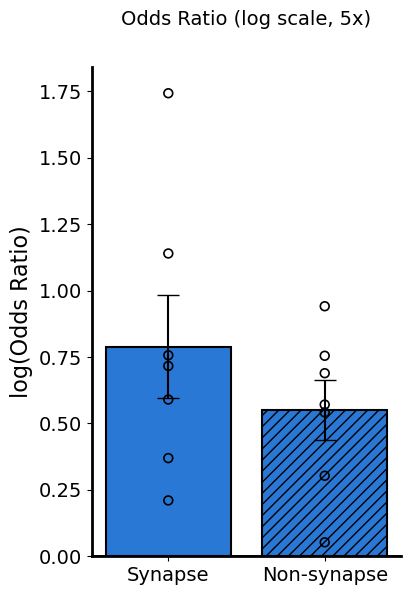


---------- STATS ----------
MB_syn_enrichment
  W statistic = 0.9175
  p-value     = 0.4501
  → Data look approximately normal

MB_non_syn_enrichment
  W statistic = 0.9714
  p-value     = 0.9082
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.0004
p-value   = 0.9841
→ Variances are not significantly different

MB_syn_enrichment
  W statistic = 0.9175
  p-value     = 0.4501
  → Data look approximately normal

MB_non_syn_enrichment
  W statistic = 0.9714
  p-value     = 0.9082
  → Data look approximately normal

Paired t-test
t statistic = 0.6777
p-value     = 0.5232
→ No significant difference detected

  Matched-pairs rank-biserial r = 0.1429
  Effect size: small

group: Synapse, mean: 1.5285714285714285, sem: 0.11489785466579745
group: Non-synapse, mean: 1.499285714285714, sem: 0.10401206758872565


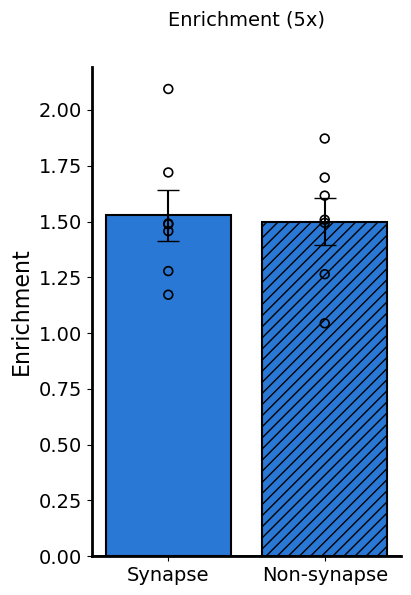

In [7]:
paired_labels = ['Synapse', 'Non-synapse']
paired_color = '#2a78d6'
paired_pattern = ['', '///']  # solid = synapse, striped = non-synapse (consistent with earlier figures)

# 5x only, per request -- not pooled across condition
df_5x = df_separator(pooled)['5x'].copy()

# log(OR) columns -- see markdown above for why OR specifically needs the log scale
df_5x['log_MB_syn_odds_ratio']     = np.log(df_5x['MB_syn_odds_ratio'])
df_5x['log_MB_non_syn_odds_ratio'] = np.log(df_5x['MB_non_syn_odds_ratio'])

# Figure 1: Fraction of HSP in Mito
fast_plotter(
    ['MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito'],
    df=df_5x, ylabel='Fraction of HSP in Mito', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Fraction of HSP in Mito (5x)', figsize=(4, 6), paired=True, quietStats=False,
)

# Figure 2: Fraction of Mito in HSP
fast_plotter(
    ['MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP'],
    df=df_5x, ylabel='Fraction of Mito in HSP', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Fraction of Mito in HSP (5x)', figsize=(4, 6), paired=True, quietStats=False,
)

# Figure 3: Odds ratio (log scale)
fast_plotter(
    ['log_MB_syn_odds_ratio', 'log_MB_non_syn_odds_ratio'],
    df=df_5x, ylabel='log(Odds Ratio)', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Odds Ratio (log scale, 5x)', figsize=(4, 6), paired=True, quietStats=False,
)

# Figure 4: Enrichment
fast_plotter(
    ['MB_syn_enrichment', 'MB_non_syn_enrichment'],
    df=df_5x, ylabel='Enrichment', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Enrichment (5x)', figsize=(4, 6), paired=True, quietStats=False,
)



---------- STATS ----------
MB_syn_fraction of HSP in Mito
  W statistic = 0.9575
  p-value     = 0.7481
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.7058
  p-value     = 0.0010
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 6.0712
p-value   = 0.0220
→ Variances differ significantly

MB_syn_fraction of HSP in Mito
  W statistic = 0.9575
  p-value     = 0.7481
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito
  W statistic = 0.7058
  p-value     = 0.0010
  → Significant deviation from normality

Wilcoxon signed-rank test
W statistic = 22.0000
p-value     = 0.2036
→ No significant difference detected

  Matched-pairs rank-biserial r = 0.4359
  Effect size: medium

group: Synapse, mean: 0.24883333333333332, sem: 0.02318203109428865
group: Non-synapse, mean: 0.21783333333333332, sem: 0.009921535601249875


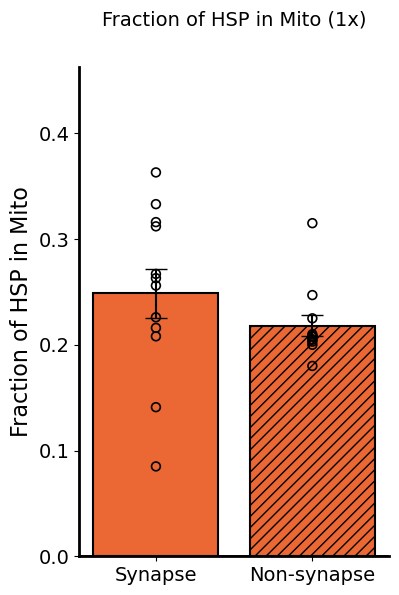


---------- STATS ----------
MB_syn_fraction of Mito in HSP
  W statistic = 0.7874
  p-value     = 0.0068
  → Significant deviation from normality

MB_non_syn_fraction of Mito in HSP
  W statistic = 0.8967
  p-value     = 0.1436
  → Data look approximately normal

Brown-Forsythe test
Statistic = 1.6858
p-value   = 0.2076
→ Variances are not significantly different

MB_syn_fraction of Mito in HSP
  W statistic = 0.7874
  p-value     = 0.0068
  → Significant deviation from normality

MB_non_syn_fraction of Mito in HSP
  W statistic = 0.8967
  p-value     = 0.1436
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 0.0000
p-value     = 0.0005
→ Significant difference between groups

  Matched-pairs rank-biserial r = 1.0000
  Effect size: large

group: Synapse, mean: 0.19100000000000006, sem: 0.028612616416221325
group: Non-synapse, mean: 0.1355, sem: 0.012257650672131264


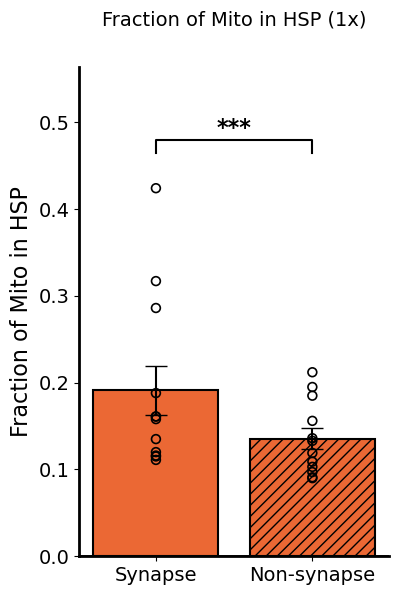


---------- STATS ----------
log_MB_syn_odds_ratio
  W statistic = 0.7436
  p-value     = 0.0023
  → Significant deviation from normality

log_MB_non_syn_odds_ratio
  W statistic = 0.8909
  p-value     = 0.1210
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.0137
p-value   = 0.9079
→ Variances are not significantly different

log_MB_syn_odds_ratio
  W statistic = 0.7436
  p-value     = 0.0023
  → Significant deviation from normality

log_MB_non_syn_odds_ratio
  W statistic = 0.8909
  p-value     = 0.1210
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 19.0000
p-value     = 0.1294
→ No significant difference detected

  Matched-pairs rank-biserial r = 0.5128
  Effect size: large

group: Synapse, mean: 0.5613740887345132, sem: 0.0650315988216018
group: Non-synapse, mean: 0.5133786162763874, sem: 0.048189339186510506


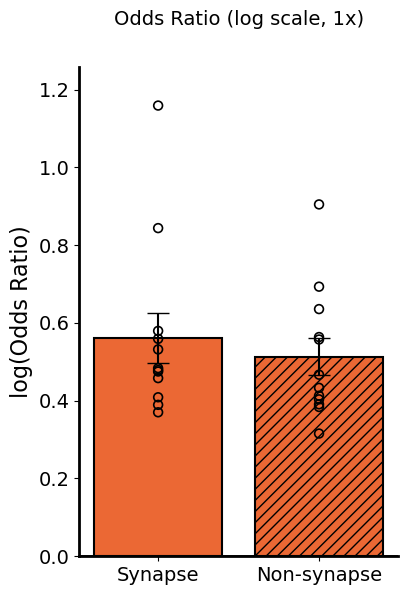


---------- STATS ----------
MB_syn_enrichment
  W statistic = 0.6679
  p-value     = 0.0004
  → Significant deviation from normality

MB_non_syn_enrichment
  W statistic = 0.8687
  p-value     = 0.0629
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.5041
p-value   = 0.4852
→ Variances are not significantly different

MB_syn_enrichment
  W statistic = 0.6679
  p-value     = 0.0004
  → Significant deviation from normality

MB_non_syn_enrichment
  W statistic = 0.8687
  p-value     = 0.0629
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 35.0000
p-value     = 0.7910
→ No significant difference detected

  Matched-pairs rank-biserial r = 0.1026
  Effect size: small

group: Synapse, mean: 1.4994166666666666, sem: 0.10435476048246928
group: Non-synapse, mean: 1.4560833333333336, sem: 0.04658528482929201


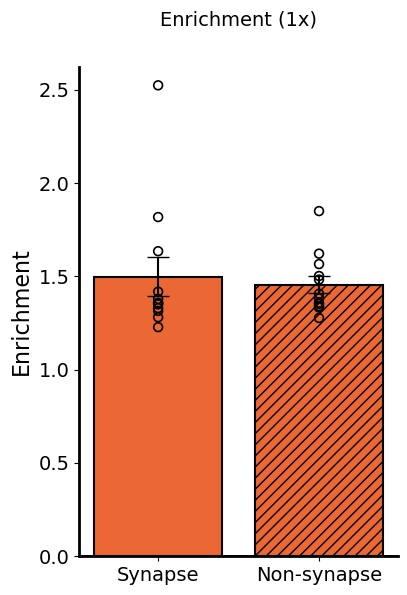

In [8]:
paired_labels = ['Synapse', 'Non-synapse']
paired_color = '#eb6834'
paired_pattern = ['', '///']  # solid = synapse, striped = non-synapse (consistent with earlier figures)

# 5x only, per request -- not pooled across condition
df_5x = df_separator(pooled)['1x'].copy()

# log(OR) columns -- see markdown above for why OR specifically needs the log scale
df_5x['log_MB_syn_odds_ratio']     = np.log(df_5x['MB_syn_odds_ratio'])
df_5x['log_MB_non_syn_odds_ratio'] = np.log(df_5x['MB_non_syn_odds_ratio'])

# Figure 1: Fraction of HSP in Mito
fast_plotter(
    ['MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito'],
    df=df_5x, ylabel='Fraction of HSP in Mito', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Fraction of HSP in Mito (1x)', figsize=(4, 6), paired=True, quietStats=False,
    title_font_size=14
)

# Figure 2: Fraction of Mito in HSP
fast_plotter(
    ['MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP'],
    df=df_5x, ylabel='Fraction of Mito in HSP', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Fraction of Mito in HSP (1x)', figsize=(4, 6), paired=True, quietStats=False,
    title_font_size=14
)

# Figure 3: Odds ratio (log scale)
fast_plotter(
    ['log_MB_syn_odds_ratio', 'log_MB_non_syn_odds_ratio'],
    df=df_5x, ylabel='log(Odds Ratio)', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Odds Ratio (log scale, 1x)', figsize=(4, 6), paired=True, quietStats=False,
    title_font_size=14
)

# Figure 4: Enrichment
fast_plotter(
    ['MB_syn_enrichment', 'MB_non_syn_enrichment'],
    df=df_5x, ylabel='Enrichment', labels=paired_labels,
    bar_color=[paired_color, paired_color], pattern=paired_pattern,
    title='Enrichment (1x)', figsize=(4, 6), paired=True, quietStats=False,
)


## Same 4 metrics, 5x and 1x side by side

Four bars per figure: `5x syn`, `5x non-syn`, `1x syn`, `1x non-syn` — 5x and 1x in different colors, synapse/non-synapse distinguished by solid/striped as before.

**Why this can't just be `fast_plotter(..., paired=True/False)`:** with 4 groups, `fast_plotter` picks *one* test for the whole set. `paired=True` would run Friedman (repeated-measures), which assumes all 4 values per row come from the same subject — untrue here, since 5x and 1x are different animals. `paired=False` would run Kruskal-Wallis, which assumes all 4 groups are fully independent — also wrong, since syn/non-syn *are* matched within each animal. The real structure is mixed, so the four comparisons below are computed directly instead, and only these four are tested (not all 6 possible pairs — e.g. `5x syn` vs `1x non-syn` doesn't answer a meaningful question here and would just add multiple-comparison noise):

- **`5x syn` vs `5x non-syn`** — paired (Wilcoxon signed-rank), same 5x animals.
- **`1x syn` vs `1x non-syn`** — paired (Wilcoxon signed-rank), same 1x animals.
- **`5x syn` vs `1x syn`** — unpaired (Mann-Whitney U), different animals, same compartment.
- **`5x non-syn` vs `1x non-syn`** — unpaired (Mann-Whitney U), different animals, same compartment.

**Known limitation (accepted for this preliminary analysis):** the unpaired 5x-vs-1x comparisons use region/hemisphere rows as the unit of analysis (n=7 vs n=12), not independent animals (true n=2 vs n=2 — 5x is almost entirely one animal, brain4, plus a single row from brain3; 1x is brain1 and brain2, 6 rows each). This is a conscious simplification given the small sample available right now, not an oversight — see the earlier discussion in this notebook/analysis for the fully animal-aggregated version if a stricter comparison is needed later.

group: 5x syn, mean: 0.3712857142857143, sem: 0.054863342903598414
group: 5x non-syn, mean: 0.21714285714285714, sem: 0.02319321387966806
group: 1x syn, mean: 0.24883333333333332, sem: 0.02318203109428865
group: 1x non-syn, mean: 0.21783333333333332, sem: 0.009921535601249875

--- Fraction of HSP in Mito ---
Paired (within 5x): synapse vs non-synapse
5x syn
  W statistic = 0.9714
  p-value     = 0.9081
  → Data look approximately normal

5x non-syn
  W statistic = 0.9896
  p-value     = 0.9925
  → Data look approximately normal

Paired t-test
t statistic = 4.7224
p-value     = 0.0032
→ Significant difference between groups

Paired (within 1x): synapse vs non-synapse
1x syn
  W statistic = 0.9575
  p-value     = 0.7481
  → Data look approximately normal

1x non-syn
  W statistic = 0.7058
  p-value     = 0.0010
  → Significant deviation from normality

Wilcoxon signed-rank test
W statistic = 22.0000
p-value     = 0.2036
→ No significant difference detected

Unpaired (5x vs 1x), synapse
5

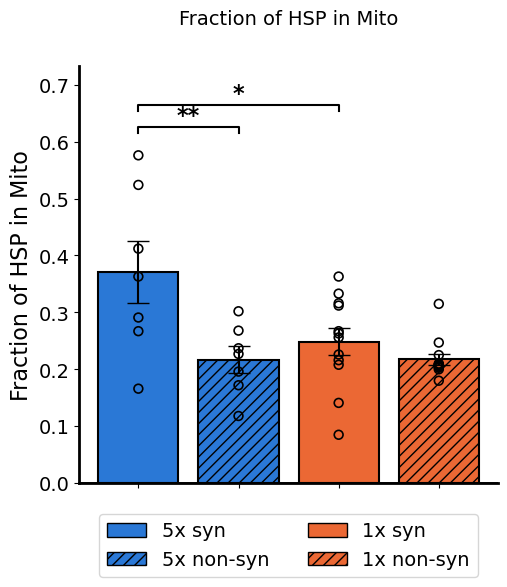

group: 5x syn, mean: 0.24814285714285716, sem: 0.04166843533661134
group: 5x non-syn, mean: 0.143, sem: 0.017211568645480724
group: 1x syn, mean: 0.19100000000000006, sem: 0.028612616416221325
group: 1x non-syn, mean: 0.1355, sem: 0.012257650672131264

--- Fraction of Mito in HSP ---
Paired (within 5x): synapse vs non-synapse
5x syn
  W statistic = 0.9290
  p-value     = 0.5421
  → Data look approximately normal

5x non-syn
  W statistic = 0.9457
  p-value     = 0.6908
  → Data look approximately normal

Paired t-test
t statistic = 3.8205
p-value     = 0.0088
→ Significant difference between groups

Paired (within 1x): synapse vs non-synapse
1x syn
  W statistic = 0.7874
  p-value     = 0.0068
  → Significant deviation from normality

1x non-syn
  W statistic = 0.8967
  p-value     = 0.1436
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 0.0000
p-value     = 0.0005
→ Significant difference between groups

Unpaired (5x vs 1x), synapse
5x syn
  W statistic = 0

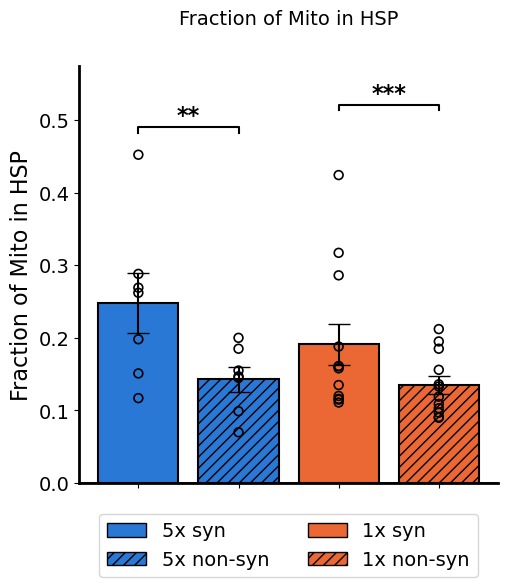

group: 5x syn, mean: 0.7893428557680676, sem: 0.1945592307992625
group: 5x non-syn, mean: 0.5504868629083063, sem: 0.11161010333155436
group: 1x syn, mean: 0.5613740887345132, sem: 0.0650315988216018
group: 1x non-syn, mean: 0.5133786162763874, sem: 0.048189339186510506

--- Odds Ratio (log scale) ---
Paired (within 5x): synapse vs non-synapse
5x syn
  W statistic = 0.9238
  p-value     = 0.4998
  → Data look approximately normal

5x non-syn
  W statistic = 0.9672
  p-value     = 0.8774
  → Data look approximately normal

Paired t-test
t statistic = 2.2861
p-value     = 0.0623
→ No significant difference detected

Paired (within 1x): synapse vs non-synapse
1x syn
  W statistic = 0.7436
  p-value     = 0.0023
  → Significant deviation from normality

1x non-syn
  W statistic = 0.8909
  p-value     = 0.1210
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 19.0000
p-value     = 0.1294
→ No significant difference detected

Unpaired (5x vs 1x), synapse
5x syn
  W 

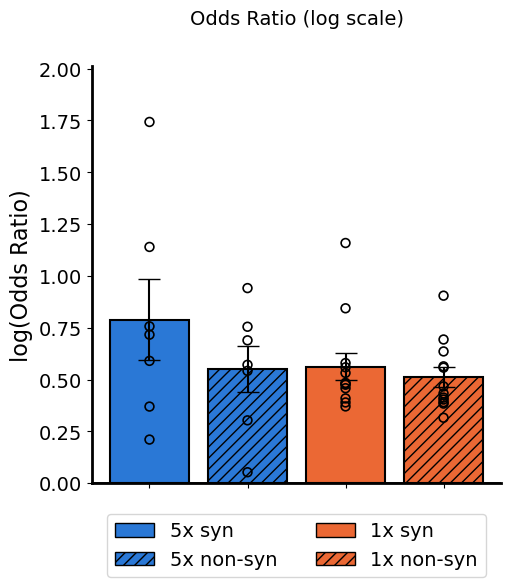

group: 5x syn, mean: 1.5285714285714285, sem: 0.11489785466579745
group: 5x non-syn, mean: 1.499285714285714, sem: 0.10401206758872565
group: 1x syn, mean: 1.4994166666666666, sem: 0.10435476048246928
group: 1x non-syn, mean: 1.4560833333333336, sem: 0.04658528482929201

--- Enrichment ---
Paired (within 5x): synapse vs non-synapse
5x syn
  W statistic = 0.9175
  p-value     = 0.4501
  → Data look approximately normal

5x non-syn
  W statistic = 0.9714
  p-value     = 0.9082
  → Data look approximately normal

Paired t-test
t statistic = 0.6777
p-value     = 0.5232
→ No significant difference detected

Paired (within 1x): synapse vs non-synapse
1x syn
  W statistic = 0.6679
  p-value     = 0.0004
  → Significant deviation from normality

1x non-syn
  W statistic = 0.8687
  p-value     = 0.0629
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 35.0000
p-value     = 0.7910
→ No significant difference detected

Unpaired (5x vs 1x), synapse
5x syn
  W statistic = 

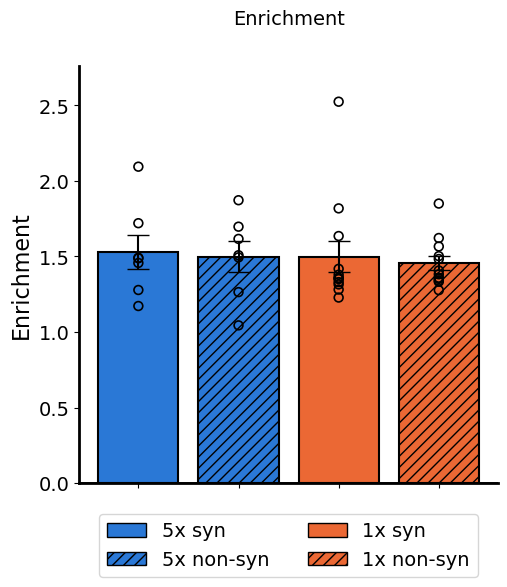

<Axes: title={'center': 'Enrichment'}, ylabel='Enrichment'>

In [9]:
def plot_condition_compartment(metric_syn, metric_non_syn, ylabel, title,
                                df_5x, df_1x, log_transform=False, figsize=(5, 6),
                                bar_color=None, pattern=None, ylim=None):
    x5_syn = df_5x[metric_syn].to_numpy(dtype=float)
    x5_non = df_5x[metric_non_syn].to_numpy(dtype=float)
    x1_syn = df_1x[metric_syn].to_numpy(dtype=float)
    x1_non = df_1x[metric_non_syn].to_numpy(dtype=float)

    if log_transform:
        x5_syn, x5_non, x1_syn, x1_non = np.log(x5_syn), np.log(x5_non), np.log(x1_syn), np.log(x1_non)

    groups = [x5_syn, x5_non, x1_syn, x1_non]
    labels = ['5x syn', '5x non-syn', '1x syn', '1x non-syn']
    # Default colors/pattern (blue=5x, orange=1x; solid=synapse, striped=non-synapse) --
    # callers with a different visual scheme (e.g. the "Density" plots below, which use
    # a separate pink/blue-family palette per channel) pass their own.
    colors = bar_color if bar_color is not None else ['#2a78d6', '#2a78d6', '#eb6834', '#eb6834']
    patterns = pattern if pattern is not None else ['', '///', '', '///']

    # plot_bars_with_sem3_test (not plot_bars_with_sem3) so title/legend styling
    # matches the density_HSP/density_Mito figures above exactly -- same function,
    # same title_font_size/pad, and a legend instead of x-tick text labels.
    ax = plot_bars_with_sem3_test(groups, labels=labels, ylabel=ylabel,
                                   bar_color=colors, pattern=patterns, figsize=figsize,
                                   title=title, title_font_size=14, legend=True)
    ax.tick_params(axis="both", labelsize=14)
    ax.yaxis.label.set_size(16)

    print(f'\n--- {title} ---')
    # two_group_test (plotter.py) -- same normality-gated test selection fast_plotter
    # uses internally (paired t-test/Wilcoxon for paired, independent t-test/Mann-Whitney
    # for unpaired), so this function can't silently drift from what fast_plotter would
    # choose for the same two groups. Previously this hardcoded wilcoxon_test/
    # mannwhitneyu_test unconditionally, which could disagree with fast_plotter's
    # (correct) choice on data that passes normality -- e.g. the 5x-only "Fraction of
    # HSP in Mito" paired comparison was significant by paired t-test (fast_plotter,
    # p=0.0165) but not by Wilcoxon (this function's old hardcoded test, p=0.047 --
    # still significant here, but the two tests don't always have to agree, and for
    # other metrics they diverged on significance entirely).
    print('Paired (within 5x): synapse vs non-synapse')
    sig_5x, p_5x = two_group_test([x5_syn, x5_non], labels=['5x syn', '5x non-syn'], paired=True)
    print('Paired (within 1x): synapse vs non-synapse')
    sig_1x, p_1x = two_group_test([x1_syn, x1_non], labels=['1x syn', '1x non-syn'], paired=True)
    print('Unpaired (5x vs 1x), synapse')
    sig_syn, p_syn = two_group_test([x5_syn, x1_syn], labels=['5x syn', '1x syn'], paired=False)
    print('Unpaired (5x vs 1x), non-synapse')
    sig_non, p_non = two_group_test([x5_non, x1_non], labels=['5x non-syn', '1x non-syn'], paired=False)

    # only these 4 biologically meaningful comparisons are tested/annotated --
    # see markdown above for why the other 2 possible cross-pairs are skipped
    candidates = [(0, 1, sig_5x, p_5x), (2, 3, sig_1x, p_1x),
                  (0, 2, sig_syn, p_syn), (1, 3, sig_non, p_non)]
    sig_pairs = [(i1, i2, p) for i1, i2, sig, p in candidates if sig]

    data_max = max(g.max() for g in groups)
    data_min = min(g.min() for g in groups)
    span = (data_max - data_min) if data_max > data_min else 1.0
    bar_step = span * 0.08
    for k, (i1, i2, p) in enumerate(sig_pairs):
        y = data_max + bar_step + k * bar_step
        add_sig_bar(ax, i1, i2, y, bar_step * 0.25, p_to_stars(p))

    if ylim is not None:
        ax.set_ylim(ylim[0], ylim[1])
    else:
        bottom = data_min - span * 0.1 if data_min < 0 else 0
        top = data_max + bar_step * (len(sig_pairs) + 2)
        ax.set_ylim(bottom, top)
    plt.show()
    return ax


df_5x = df_separator(pooled)['5x'].copy()
df_1x = df_separator(pooled)['1x'].copy()

plot_condition_compartment(
    'MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito',
    'Fraction of HSP in Mito', 'Fraction of HSP in Mito', df_5x, df_1x,
)

plot_condition_compartment(
    'MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP',
    'Fraction of Mito in HSP', 'Fraction of Mito in HSP', df_5x, df_1x,
)

plot_condition_compartment(
    'MB_syn_odds_ratio', 'MB_non_syn_odds_ratio',
    'log(Odds Ratio)', 'Odds Ratio (log scale)', df_5x, df_1x, log_transform=True,
)

plot_condition_compartment(
    'MB_syn_enrichment', 'MB_non_syn_enrichment',
    'Enrichment', 'Enrichment', df_5x, df_1x,
)


group: 5x syn, mean: 0.15622857142857144, sem: 0.015237449391075207
group: 5x non-syn, mean: 0.09324285714285714, sem: 0.006192463051117526
group: 1x syn, mean: 0.13521666666666668, sem: 0.02460997221297156
group: 1x non-syn, mean: 0.09204166666666669, sem: 0.006652790008634716

--- "Density" of HSP ---
Paired (within 5x): synapse vs non-synapse
5x syn
  W statistic = 0.9662
  p-value     = 0.8696
  → Data look approximately normal

5x non-syn
  W statistic = 0.9630
  p-value     = 0.8442
  → Data look approximately normal

Paired t-test
t statistic = 6.0452
p-value     = 0.0009
→ Significant difference between groups

Paired (within 1x): synapse vs non-synapse
1x syn
  W statistic = 0.7420
  p-value     = 0.0022
  → Significant deviation from normality

1x non-syn
  W statistic = 0.8647
  p-value     = 0.0561
  → Data look approximately normal

Wilcoxon signed-rank test
W statistic = 4.0000
p-value     = 0.0034
→ Significant difference between groups

Unpaired (5x vs 1x), synapse
5x s

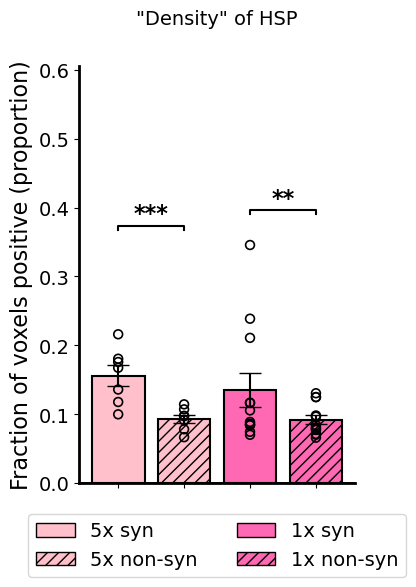

group: 5x syn, mean: 0.23572857142857145, sem: 0.021230612604553497
group: 5x non-syn, mean: 0.14244285714285715, sem: 0.006373227377936891
group: 1x syn, mean: 0.177925, sem: 0.021278873877271995
group: 1x non-syn, mean: 0.14944166666666667, sem: 0.003652198556065824

--- "Density" of Mito ---
Paired (within 5x): synapse vs non-synapse
5x syn
  W statistic = 0.9526
  p-value     = 0.7529
  → Data look approximately normal

5x non-syn
  W statistic = 0.9467
  p-value     = 0.6994
  → Data look approximately normal

Paired t-test
t statistic = 6.1638
p-value     = 0.0008
→ Significant difference between groups

Paired (within 1x): synapse vs non-synapse
1x syn
  W statistic = 0.9397
  p-value     = 0.4947
  → Data look approximately normal

1x non-syn
  W statistic = 0.9749
  p-value     = 0.9546
  → Data look approximately normal

Paired t-test
t statistic = 1.1674
p-value     = 0.2677
→ No significant difference detected

Unpaired (5x vs 1x), synapse
5x syn
  W statistic = 0.9526
  p-

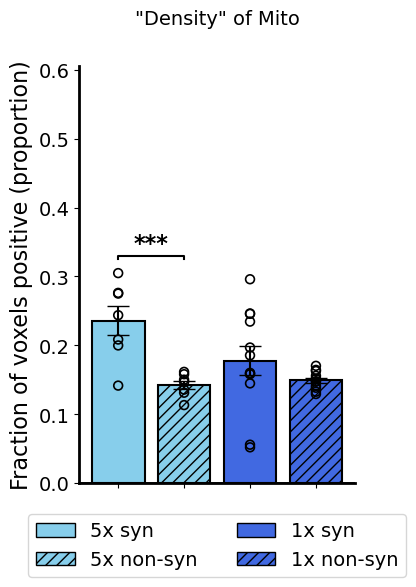

<Axes: title={'center': '"Density" of Mito'}, ylabel='Fraction of voxels positive (proportion)'>

In [10]:
# density_HSP_* / density_Mito_* are defined in colocalization.py as
# (channel-positive voxels) / (voxels in that compartment) -- i.e. the fraction of
# the synaptic/non-synaptic compartment's volume that is channel-positive. That's a
# dimensionless proportion (0-1), not a physical density -- labelled accordingly below,
# and "Density" is kept in quotes in the titles for the same reason.
#
# Uses plot_condition_compartment (defined above), not a direct fast_plotter call on
# all 4 bars, for the same reason as the OR/enrichment/fraction comparisons above:
# syn and non-syn come from the same animal (paired within each condition), while 5x
# vs 1x are different animals (unpaired) -- a plain 4-group fast_plotter call would run
# a one-way ANOVA/Kruskal treating all 4 bars as independent samples, which the
# syn/non-syn pair is not. plot_condition_compartment runs the correct targeted mix:
# 2 paired tests (within 5x, within 1x) + 2 unpaired tests (5x vs 1x, per compartment).
# Bar colors/patterns/labels/ylabel/figsize/legend are passed through unchanged from
# the original direct-fast_plotter version of this cell, so the figures look identical.

density_ylabel = 'Fraction of voxels positive (proportion)'

# Shared y-limit across both figures (same rationale as before: makes HSP and Mito
# "density" directly comparable on one scale) -- nanmax because a sample with zero
# synaptic or non-synaptic voxels gets NaN from colocalization.py's density
# calculation, and reserve headroom using the same formula fast_plotter/
# plot_condition_compartment use for significance brackets (data_max + 0.1 + 0.04 per
# bracket), capped at up to 4 brackets so it stays correct regardless of exactly which
# comparisons are significant.
_hsp_vals = np.concatenate([df_5x['density_HSP_syn'], df_5x['density_HSP_non_syn'],
                             df_1x['density_HSP_syn'], df_1x['density_HSP_non_syn']])
_mito_vals = np.concatenate([df_5x['density_Mito_syn'], df_5x['density_Mito_non_syn'],
                              df_1x['density_Mito_syn'], df_1x['density_Mito_non_syn']])
shared_max = max(np.nanmax(_hsp_vals), np.nanmax(_mito_vals))
shared_ylim = (0, shared_max + 0.1 + 0.04 * 4)

# Figure 1: Density of HSP
plot_condition_compartment(
    'density_HSP_syn', 'density_HSP_non_syn', density_ylabel, '"Density" of HSP',
    df_5x, df_1x, figsize=(4, 6),
    bar_color=['pink', 'pink', 'hotpink', 'hotpink'], pattern=['', '///', '', '///'],
    ylim=shared_ylim,
)

# Figure 2: Density of Mito
plot_condition_compartment(
    'density_Mito_syn', 'density_Mito_non_syn', density_ylabel, '"Density" of Mito',
    df_5x, df_1x, figsize=(4, 6),
    bar_color=['skyblue', 'skyblue', 'royalblue', 'royalblue'], pattern=['', '///', '', '///'],
    ylim=shared_ylim,
)
